In [1]:
import pandas as pd
import numpy as np

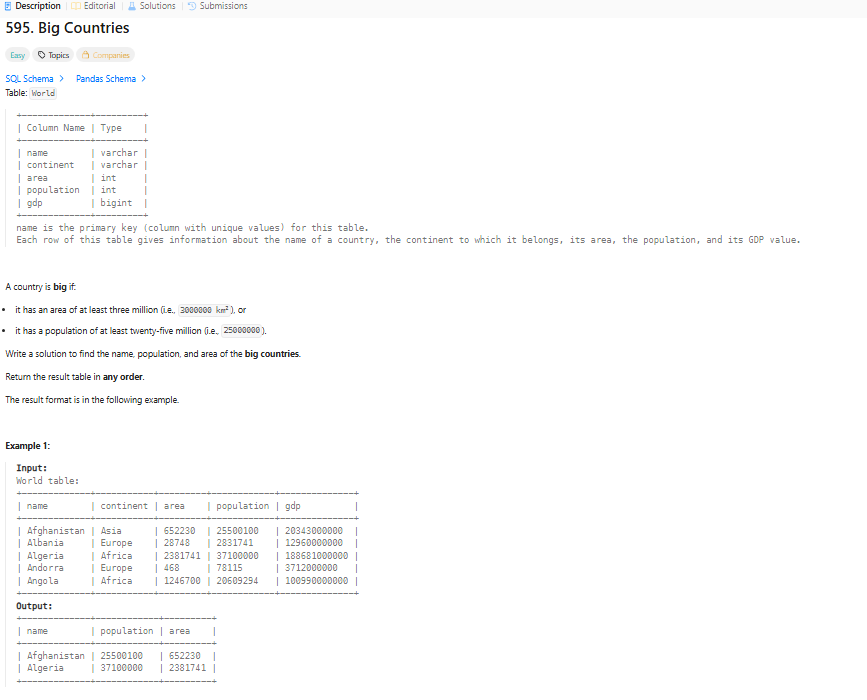

In [2]:
data = [['Afghanistan', 'Asia', 652230, 25500100, 20343000000], ['Albania', 'Europe', 28748, 2831741, 12960000000], ['Algeria', 'Africa', 2381741, 37100000, 188681000000], ['Andorra', 'Europe', 468, 78115, 3712000000], ['Angola', 'Africa', 1246700, 20609294, 100990000000]]
world = pd.DataFrame(data, columns=['name', 'continent', 'area', 'population', 'gdp']).astype({'name':'object', 'continent':'object', 'area':'Int64', 'population':'Int64', 'gdp':'Int64'})

In [3]:
world

,name,continent,area,population,gdp
0,Afghanistan,Asia,652230,25500100,20343000000
1,Albania,Europe,28748,2831741,12960000000
2,Algeria,Africa,2381741,37100000,188681000000
3,Andorra,Europe,468,78115,3712000000
4,Angola,Africa,1246700,20609294,100990000000


In [15]:

def big_countries(world: pd.DataFrame) -> pd.DataFrame:
    big_area=3000000 
    high_pop=25000000
    return world[(world['area']>=big_area)| (world['population']>=high_pop)][['name', 'population', 'area']]

In [16]:
big_countries(world)

,name,population,area
0,Afghanistan,25500100,652230
2,Algeria,37100000,2381741


In [18]:
data = [['0', 'Y', 'N'], ['1', 'Y', 'Y'], ['2', 'N', 'Y'], ['3', 'Y', 'Y'], ['4', 'N', 'N']]
products = pd.DataFrame(data, columns=['product_id', 'low_fats', 'recyclable']).astype({'product_id':'int64', 'low_fats':'category', 'recyclable':'category'})

In [27]:
def find_products(products: pd.DataFrame) -> pd.DataFrame:
    return products[(products['low_fats']=='Y') & (products['recyclable']=='Y')][['product_id']]

In [28]:
find_products(products)

,product_id
1,1
3,3


Write a solution to find all customers who never order anything.

Return the result table in any order.

The result format is in the following example.

In [29]:
data = [[1, 'Joe'], [2, 'Henry'], [3, 'Sam'], [4, 'Max']]
customers = pd.DataFrame(data, columns=['id', 'name']).astype({'id':'Int64', 'name':'object'})
data = [[1, 3], [2, 1]]
orders = pd.DataFrame(data, columns=['id', 'customerId']).astype({'id':'Int64', 'customerId':'Int64'})

In [32]:
def find_customers(customers: pd.DataFrame, orders: pd.DataFrame) -> pd.DataFrame:
    return customers[~customers['id'].isin(orders['customerId'])][['name']].rename(columns={'name':'Customers'})

In [33]:
find_customers(customers, orders)

,Customers
1,Henry
3,Max


Write a solution to find all the authors that viewed at least one of their own articles.

Return the result table sorted by id in ascending order.

The result format is in the following example.

In [34]:
data = [[1, 3, 5, '2019-08-01'], [1, 3, 6, '2019-08-02'], [2, 7, 7, '2019-08-01'], [2, 7, 6, '2019-08-02'], [4, 7, 1, '2019-07-22'], [3, 4, 4, '2019-07-21'], [3, 4, 4, '2019-07-21']]
views = pd.DataFrame(data, columns=['article_id', 'author_id', 'viewer_id', 'view_date']).astype({'article_id':'Int64', 'author_id':'Int64', 'viewer_id':'Int64', 'view_date':'datetime64[ns]'})

In [56]:
# Authors who viewed at least one of their own articles
def article_views(views: pd.DataFrame) -> pd.DataFrame:
    return (
        views.loc[views["author_id"] == views["viewer_id"], ["author_id"]]
        .drop_duplicates()
        .sort_values("author_id")
        .reset_index(drop=True)
    )

article_views(views)

,author_id
0,4
1,7


,id
0,4
1,7
